In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dow30_tickers = [
    "AAPL","MSFT","JPM","GS","NKE","DIS","IBM","INTC","KO","MCD",
    "MMM","V","WMT","CVX","XOM","CAT","BA","AXP","HD","UNH",
    "PG","TRV","VZ","CSCO","MRK","JNJ","AMGN","CRM","HON","DOW"
]


In [3]:
#download the data 
data=yf.download(dow30_tickers,start="2010-01-01",end="2024-01-01",interval="1d",group_by="ticker",auto_adjust=True)
#group_by-> Group by ‘ticker’ or ‘column’ (default)
#auto_adjust: bool  Adjust all OHLC automatically? Default is True

[*********************100%***********************]  30 of 30 completed

26 Failed downloads:
['AAPL', 'MSFT', 'MRK', 'INTC', 'GS', 'CRM', 'TRV', 'IBM', 'CVX', 'NKE', 'HD', 'HON', 'UNH', 'MCD', 'AMGN', 'CAT', 'DIS', 'WMT', 'AXP', 'XOM', 'JNJ', 'V', 'PG', 'JPM', 'KO', 'BA']: TypeError("'NoneType' object is not subscriptable")


In [4]:
data

Ticker           CSCO                                                    VZ  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2010-01-04  15.516330  15.986131  15.451973  15.889597  59853700  13.364389   
2010-01-05  15.831682  15.915345  15.690097  15.818810  45124500  13.352386   
2010-01-06  15.793066  15.921778  15.664352  15.715837  35715700  13.249053   
2010-01-07  15.638600  15.812362  15.554937  15.786620  31531200  13.029858   
2010-01-08  15.690090  15.896031  15.606427  15.870288  39115900  12.851257   
...               ...        ...        ...        ...       ...        ...   
2023-12-22  46.552660  47.066383  46.552660  46.786171  12903800  31.784657   
2023-12-26  46.804845  47.075718  46.748801  46.963631   9721200  31.801636   
2023-12-27  46.982318  47.225171  46.963636  47.113083  10414300  31.708208   
2023-12-28  47.243850  47.290552  47.094400  47.150444   8549900  31.580802   
2023-12-29  47.122423  47.253188  46.907593  47.187805  12492900  31.750679   

Ticker                                                 ...  KO        \
Price            High        Low      Close    Volume  ... Low Close   
Date                                                   ...             
2010-01-04  13.384395  13.240348  13.316373  16176648  ... NaN   NaN   
2010-01-05  13.364390  13.116308  13.340382  23722957  ... NaN   NaN   
2010-01-06  13.289644  12.908084  12.956794  37506464  ... NaN   NaN   
2010-01-07  13.029858  12.798486  12.879669  25508242  ... NaN   NaN   
2010-01-08  12.899966  12.753837  12.887789  20658308  ... NaN   NaN   
...               ...        ...        ...       ...  ...  ..   ...   
2023-12-22  32.090443  31.767672  31.844118  13171600  ... NaN   NaN   
2023-12-26  31.971518  31.691216  31.835613  11856600  ... NaN   NaN   
2023-12-27  31.818628  31.597785  31.691219  15267600  ... NaN   NaN   
2023-12-28  32.039480  31.555321  31.844118  14931700  ... NaN   NaN   
2023-12-29  32.073450  31.699714  32.022488  16222700  ... NaN   NaN   

Ticker                        BA                                  
Price      Adj Close Volume Open High Low Close Adj Close Volume  
Date                                                              
2010-01-04       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  
2010-01-05       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  
2010-01-06       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  
2010-01-07       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  
2010-01-08       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  
...              ...    ...  ...  ...  ..   ...       ...    ...  
2023-12-22       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  
2023-12-26       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  
2023-12-27       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  
2023-12-28       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  
2023-12-29       NaN    NaN  NaN  NaN NaN   NaN       NaN    NaN  

[3522 rows x 176 columns]

In [5]:
print(data.info())
data.columns

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3522 entries, 2010-01-04 to 2023-12-29
Columns: 176 entries, ('CSCO', 'Open') to ('BA', 'Volume')
dtypes: float64(173), int64(3)
memory usage: 4.8 MB
None


MultiIndex([('CSCO',      'Open'),
            ('CSCO',      'High'),
            ('CSCO',       'Low'),
            ('CSCO',     'Close'),
            ('CSCO',    'Volume'),
            (  'VZ',      'Open'),
            (  'VZ',      'High'),
            (  'VZ',       'Low'),
            (  'VZ',     'Close'),
            (  'VZ',    'Volume'),
            ...
            (  'KO',       'Low'),
            (  'KO',     'Close'),
            (  'KO', 'Adj Close'),
            (  'KO',    'Volume'),
            (  'BA',      'Open'),
            (  'BA',      'High'),
            (  'BA',       'Low'),
            (  'BA',     'Close'),
            (  'BA', 'Adj Close'),
            (  'BA',    'Volume')],
           names=['Ticker', 'Price'], length=176)

In [6]:
type(data)

pandas.core.frame.DataFrame

In [7]:
close_price=pd.DataFrame()

for ticker in  dow30_tickers:
    close_price[ticker]=data[ticker]["Close"]

In [8]:
close_price.head()

,AAPL,MSFT,JPM,GS,NKE,DIS,IBM,INTC,KO,MCD,...,PG,TRV,VZ,CSCO,MRK,JNJ,AMGN,CRM,HON,DOW
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.316373,15.889597,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.340382,15.818810,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12.956794,15.715837,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12.879669,15.786620,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12.887789,15.870288,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
close_price.tail()

,AAPL,MSFT,JPM,GS,NKE,DIS,IBM,INTC,KO,MCD,...,PG,TRV,VZ,CSCO,MRK,JNJ,AMGN,CRM,HON,DOW
Date,,,,,,,,,,,,,,,,,,,,,
2023-12-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,31.844118,46.786171,NaN,NaN,NaN,NaN,NaN,48.036888
2023-12-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,31.835613,46.963631,NaN,NaN,NaN,NaN,NaN,48.551067
2023-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,31.691219,47.113083,NaN,NaN,NaN,NaN,NaN,48.551067
2023-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,31.844118,47.150444,NaN,NaN,NaN,NaN,NaN,48.132751
2023-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,32.022488,47.187805,NaN,NaN,NaN,NaN,NaN,47.792870


In [10]:
print(close_price.isna().sum())
close_price.isna().sum().sum()

AAPL    3522
MSFT    3522
JPM     3522
GS      3522
NKE     3522
DIS     3522
IBM     3522
INTC    3522
KO      3522
MCD     3522
MMM        0
V       3522
WMT     3522
CVX     3522
XOM     3522
CAT     3522
BA      3522
AXP     3522
HD      3522
UNH     3522
PG      3522
TRV     3522
VZ         0
CSCO       0
MRK     3522
JNJ     3522
AMGN    3522
CRM     3522
HON     3522
DOW     2317
dtype: int64


np.int64(93889)

In [11]:
#there are 2317 missing values
close_price=close_price.dropna()
print(close_price.isna().sum().sum())
close_price.info()

0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    0 non-null      float64
 1   MSFT    0 non-null      float64
 2   JPM     0 non-null      float64
 3   GS      0 non-null      float64
 4   NKE     0 non-null      float64
 5   DIS     0 non-null      float64
 6   IBM     0 non-null      float64
 7   INTC    0 non-null      float64
 8   KO      0 non-null      float64
 9   MCD     0 non-null      float64
 10  MMM     0 non-null      float64
 11  V       0 non-null      float64
 12  WMT     0 non-null      float64
 13  CVX     0 non-null      float64
 14  XOM     0 non-null      float64
 15  CAT     0 non-null      float64
 16  BA      0 non-null      float64
 17  AXP     0 non-null      float64
 18  HD      0 non-null      float64
 19  UNH     0 non-null      float64
 20  PG      0 non-null      float64
 21  TRV     0 non-null      float64
 22  VZ      0

In [12]:
close_price.to_csv("dj30_close_price.csv")

In [13]:
#now we check the return value
returns = close_price.pct_change().dropna()  #pct_change - method to calculate the percentage change btw current and prior element in dataframe
#here we use dropna bcz it create first row to NaN 

In [14]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    0 non-null      float64
 1   MSFT    0 non-null      float64
 2   JPM     0 non-null      float64
 3   GS      0 non-null      float64
 4   NKE     0 non-null      float64
 5   DIS     0 non-null      float64
 6   IBM     0 non-null      float64
 7   INTC    0 non-null      float64
 8   KO      0 non-null      float64
 9   MCD     0 non-null      float64
 10  MMM     0 non-null      float64
 11  V       0 non-null      float64
 12  WMT     0 non-null      float64
 13  CVX     0 non-null      float64
 14  XOM     0 non-null      float64
 15  CAT     0 non-null      float64
 16  BA      0 non-null      float64
 17  AXP     0 non-null      float64
 18  HD      0 non-null      float64
 19  UNH     0 non-null      float64
 20  PG      0 non-null      float64
 21  TRV     0 non-null      float64
 22  VZ      0 n

In [15]:
returns.head()

,AAPL,MSFT,JPM,GS,NKE,DIS,IBM,INTC,KO,MCD,...,PG,TRV,VZ,CSCO,MRK,JNJ,AMGN,CRM,HON,DOW
Date,,,,,,,,,,,,,,,,,,,,,


In [16]:
returns.describe()

,AAPL,MSFT,JPM,GS,NKE,DIS,IBM,INTC,KO,MCD,...,PG,TRV,VZ,CSCO,MRK,JNJ,AMGN,CRM,HON,DOW
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Compare the 50% (Median) to the Mean:-
    * If Mean > 50%: Your stock has "positive skew" (occasional massive price spikes).
    * If Mean < 50%: Your stock has "negative skew" (occasional massive crashes).

In [17]:
returns.to_csv("dj30_daily_returns.csv")

In [18]:
close_price.index

DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None)

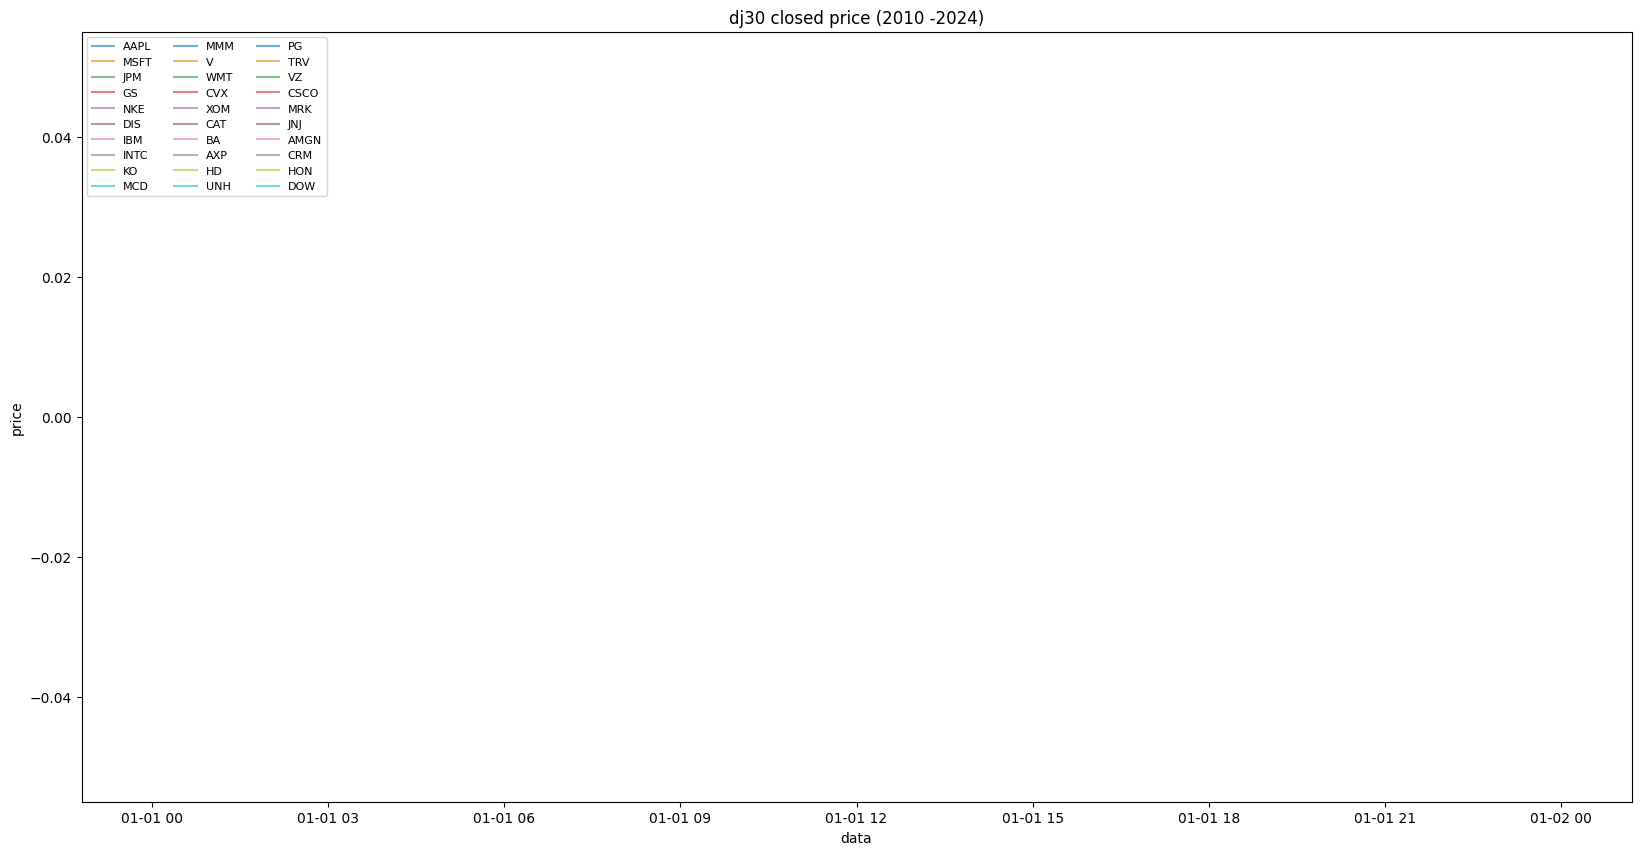

In [19]:
#plot the data
plt.figure(figsize=(20,10))
for ticker in close_price.columns:
    plt.plot(close_price.index,close_price[ticker],label=ticker,alpha=0.6)

plt.title("dj30 closed price (2010 -2024)")
plt.xlabel("data")
plt.ylabel("price")
plt.legend(loc="upper left",ncol=3,fontsize=8)
plt.show()

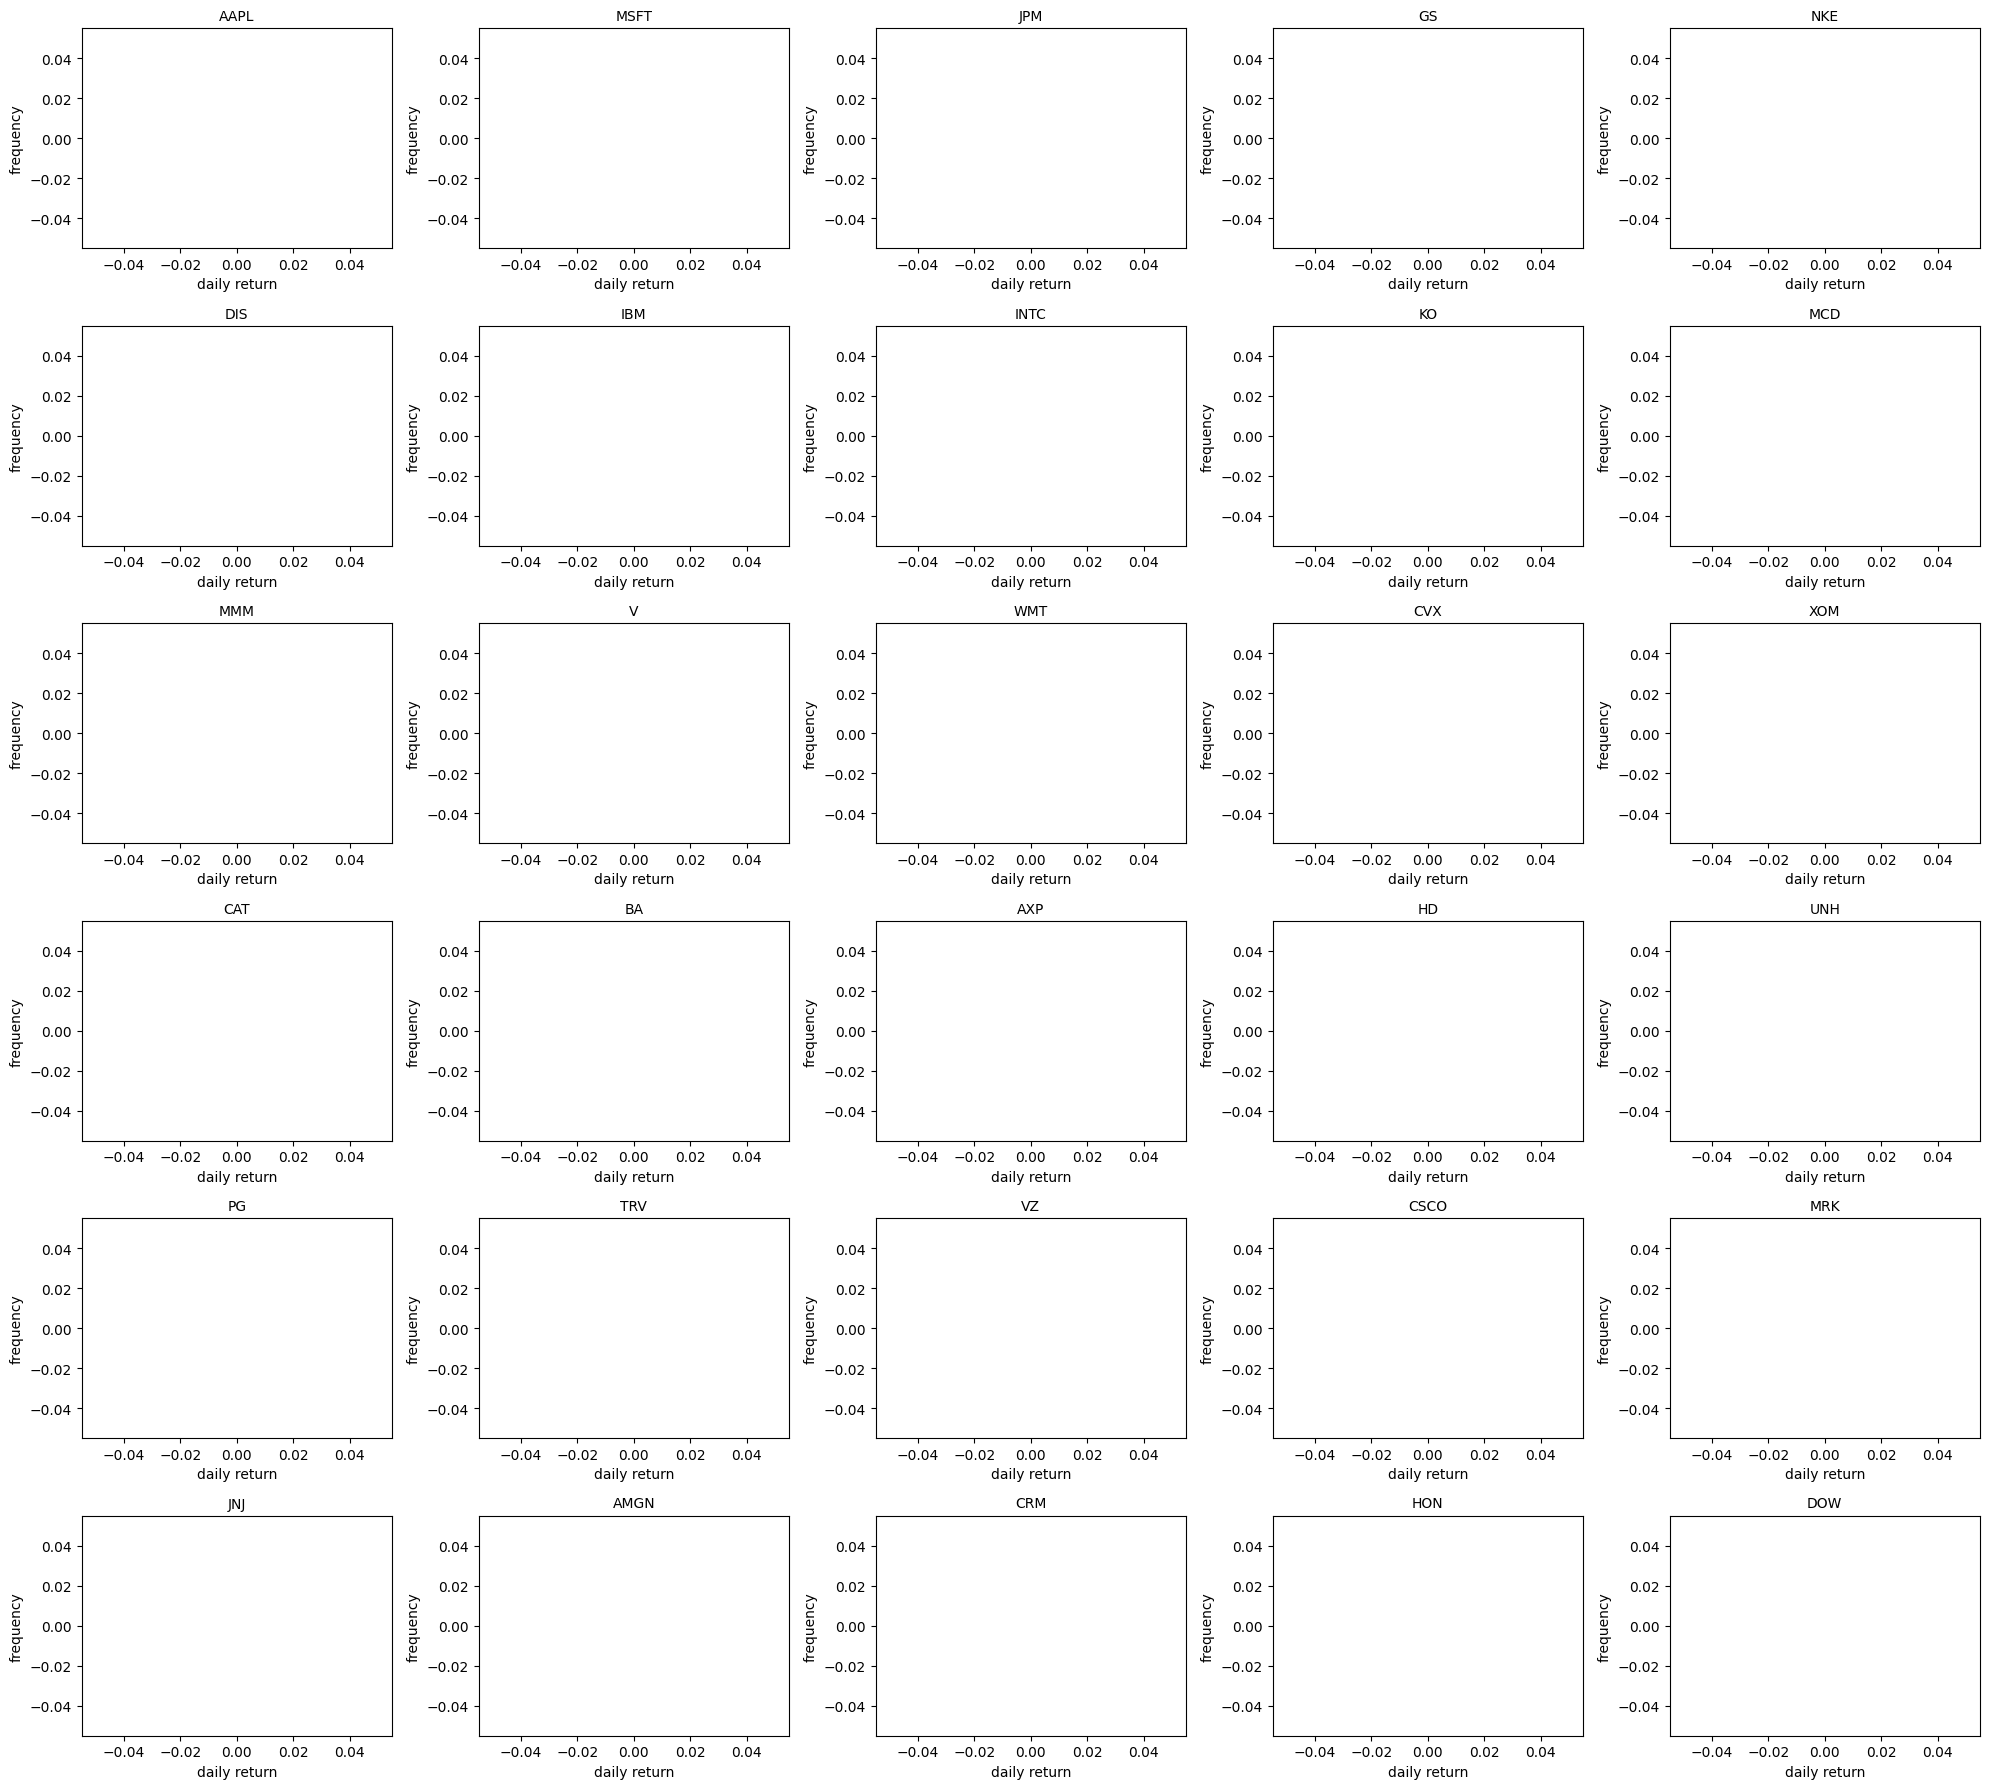

In [20]:
ticks=len(returns.columns)
rows,cols=6,5
fig,a=plt.subplots(rows,cols,figsize=(20,18))

a=a.flatten() #convert 2d grid into 1d grid of (30 items)
for i,ticker in enumerate(returns.columns):
    sns.histplot(returns[ticker],bins=100,kde=True,ax=a[i])  #ax here to give specific axix to plot data
    a[i].set_title(ticker,fontsize=10)
    a[i].set_xlabel("daily return")
    a[i].set_ylabel("frequency")
plt.tight_layout()
plt.show()

### Feature engineering
* Raw returns tell the agent what happened yesterday, but they don't give it a sense of momentum or trend.
* so we have to append the feature:-
    * **momentum**-Moving Average Convergence Divergence (MACD) or Relative Strength Index (RSI).
    * **Risk/volatility**-A 20-day rolling standard deviation of returns. (Crucial for a risk-aware agent).
    * **covariance**- For portfolio optimization, the agent needs to know how the 30 stocks interact. Rolling covariance matrices are often flattened and added to the state

In [21]:
returns=pd.read_csv('data/dj30_daily_returns.csv',index_col=0,parse_dates=True)
print(returns)


                AAPL      MSFT       JPM        GS       NKE       DIS  \
Date                                                                     
2019-03-21  0.036830  0.022975 -0.015786  0.001338  0.015227 -0.012092   
2019-03-22 -0.020708 -0.026368 -0.030233 -0.028883 -0.066129 -0.003957   
2019-03-25 -0.012091  0.005211 -0.008320 -0.002381  0.001703 -0.004066   
2019-03-26 -0.010332  0.002125  0.010007  0.011564  0.012754  0.021802   
2019-03-27  0.008994 -0.009669 -0.003402 -0.003461 -0.003478  0.001271   
...              ...       ...       ...       ...       ...       ...   
2023-12-22 -0.005548  0.002784 -0.000597  0.000210 -0.118257 -0.010867   
2023-12-26 -0.002841  0.000214  0.005914  0.002522 -0.000185 -0.000769   
2023-12-27  0.000518 -0.001575  0.005998  0.007521 -0.008239 -0.006267   
2023-12-28  0.002226  0.003235  0.005313  0.005020  0.015775  0.000221   
2023-12-29 -0.005424  0.002025 -0.001174 -0.001656 -0.002297 -0.001217   

                 IBM      INTC       

In [22]:
returns.index.name='date'
returns.index.name

'date'

* index_col= - Tells Pandas to use the first column (column 0) of the CSV as the DataFrame’s index.
* parse_dates:-
    * - Instructs Pandas to automatically interpret date strings as datetime objects.
    * - Without this, the date column would just be text (strings), which makes time‑based operations (rolling windows, resampling) harder.
    * eg - df['2020'].mean() or df.loc['2020-01-01']

In [23]:
prices=pd.read_csv("data/dj30_close_price.csv",index_col=0,parse_dates=True)
prices

,AAPL,MSFT,JPM,GS,NKE,DIS,IBM,INTC,KO,MCD,...,PG,TRV,VZ,CSCO,MRK,JNJ,AMGN,CRM,HON,DOW
Date,,,,,,,,,,,,,,,,,,,,,
2019-03-20,44.918926,110.426811,86.207199,165.761169,79.331825,106.161964,99.528450,46.612232,37.032742,158.202209,...,85.267494,113.666084,39.019638,43.311523,63.478340,113.527618,155.390823,161.547150,128.076920,34.132927
2019-03-21,46.573307,112.963852,84.846313,165.982925,80.539772,104.878258,100.840309,47.322411,37.016460,159.399582,...,85.912926,116.297226,39.439144,43.864517,64.151169,114.197433,156.016907,164.945862,129.847031,33.570904
2019-03-22,45.608856,109.985184,82.281197,161.188904,75.213783,104.463226,99.421509,46.127228,37.358086,159.775955,...,85.217171,116.755920,40.433739,42.888657,63.640759,113.213417,151.797165,159.561264,127.699936,33.310452
2019-03-25,45.057396,110.558342,81.596619,160.805038,75.341873,104.038528,99.229042,45.711514,37.439423,158.843704,...,85.468643,116.799202,40.650269,42.880531,63.687172,112.965347,151.707718,158.948715,127.781944,33.687428
2019-03-26,44.591881,110.793282,82.413139,162.664627,76.302757,106.306747,99.970497,46.283127,37.935570,160.348984,...,86.357201,116.825180,41.022388,43.287136,64.127983,114.586113,153.073654,157.486511,129.052139,33.481808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,191.788742,369.077118,159.387573,364.214203,103.780037,89.215660,152.541840,47.365639,54.969814,278.306915,...,137.128754,179.552383,32.323074,47.039684,101.039940,146.213623,267.130524,263.142761,185.710266,48.605850
2023-12-26,191.243912,369.155945,160.330200,365.132782,103.760826,89.147057,153.548508,49.832600,55.196026,279.413666,...,137.751724,180.799011,32.314449,47.218113,100.974281,146.853180,266.886047,263.024170,187.877686,49.126125
2023-12-27,191.342957,368.574646,161.291855,367.878876,102.905914,88.588356,153.783691,50.089161,55.337406,281.026031,...,137.864960,182.277557,32.167885,47.368370,101.302635,147.050690,269.358459,263.518219,188.762695,49.126125


In [24]:
prices.index.name='date'
prices.index.name

'date'

In [25]:
volatility=returns.rolling(21).std()
volatility 
##- measure of risk/uncertainty — higher values mean the stock has been more volatile recently.


,AAPL,MSFT,JPM,GS,NKE,DIS,IBM,INTC,KO,MCD,...,PG,TRV,VZ,CSCO,MRK,JNJ,AMGN,CRM,HON,DOW
date,,,,,,,,,,,,,,,,,,,,,
2019-03-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,0.009012,0.009545,0.007008,0.016670,0.029113,0.012740,0.006818,0.019045,0.007817,0.008653,...,0.012738,0.008114,0.010101,0.007486,0.010619,0.010168,0.010805,0.024403,0.008957,0.012498
2023-12-26,0.008881,0.009544,0.006986,0.016657,0.029104,0.012432,0.006873,0.021678,0.007847,0.008664,...,0.012781,0.008074,0.010097,0.007447,0.010648,0.009952,0.010848,0.024448,0.009132,0.012580
2023-12-27,0.008872,0.009514,0.006820,0.016487,0.029164,0.012366,0.006875,0.021661,0.007842,0.008637,...,0.012792,0.008131,0.010142,0.007028,0.010515,0.009728,0.010772,0.024447,0.009037,0.012154


In [26]:
momentum=returns.rolling(21).sum() 
momentum  #Adds up the daily returns over the past 21 days.

,AAPL,MSFT,JPM,GS,NKE,DIS,IBM,INTC,KO,MCD,...,PG,TRV,VZ,CSCO,MRK,JNJ,AMGN,CRM,HON,DOW
date,,,,,,,,,,,,,,,,,,,,,
2019-03-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,0.012711,-0.007775,0.088467,0.128220,0.013538,-0.038609,0.044707,0.098367,0.006833,0.040829,...,-0.037076,0.059950,0.004760,0.041553,0.065957,0.031356,0.072640,0.180308,0.067922,0.085221
2023-12-26,0.016875,-0.006450,0.093012,0.129237,0.015948,-0.049791,0.050984,0.143810,0.008381,0.042642,...,-0.034917,0.058601,0.002886,0.039522,0.063439,0.024591,0.068437,0.177445,0.073873,0.090672
2023-12-27,0.018341,-0.011151,0.101289,0.141003,0.004736,-0.046793,0.050003,0.146228,0.012820,0.050890,...,-0.033170,0.060752,-0.000045,0.051596,0.071010,0.033936,0.082184,0.177496,0.080859,0.101316


In [27]:
#SMA(simple moving average ratio(price vs average)
sma_21=prices.rolling(21).mean()
sma_ratio=prices/sma_21

##- If ratio > 1 → price is above average (bullish).
##- If ratio < 1 → price is below average (bearish).


In [28]:
vix=yf.download("^VIX",start="2010-01-01",end="2024-01-01",auto_adjust=True)['Close']


[*********************100%***********************]  1 of 1 completed


In [29]:
vix # tells when to take risk 
#low vix mean take risk(market is calm) ,high vix mean not take risk (market is not calm)

Ticker,^VIX
Date,
2010-01-04,20.040001
2010-01-05,19.350000
2010-01-06,19.160000
2010-01-07,19.059999
2010-01-08,18.129999
...,...
2023-12-22,13.030000
2023-12-26,12.990000
2023-12-27,12.430000


In [30]:
vix.isna().sum()

Ticker
^VIX    0
dtype: int64

In [31]:
vix.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3522 entries, 2010-01-04 to 2023-12-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^VIX    3522 non-null   float64
dtypes: float64(1)
memory usage: 55.0 KB


In [32]:
if isinstance(vix,pd.DataFrame):
    vix=vix.squeeze()  #back to series data


In [33]:
vix=vix.reindex(returns.index)
vix
## make sure the vix has same index as main dataset

date
2019-03-21    13.63
2019-03-22    16.48
2019-03-25    16.33
2019-03-26    14.68
2019-03-27    15.15
              ...  
2023-12-22    13.03
2023-12-26    12.99
2023-12-27    12.43
2023-12-28    12.47
2023-12-29    12.45
Name: ^VIX, Length: 1204, dtype: float64

In [34]:
type(vix)

pandas.core.series.Series

In [35]:
vix.ffill()
# we can use ffill here because there is less missing values available.
# eg if data not in mon then the fill form tue .
print(type(vix))

<class 'pandas.core.series.Series'>


In [36]:
#now calulate z score norm
vix_z=(vix-vix.rolling(60).mean())/vix.rolling(60).std()
vix_z

date
2019-03-21         NaN
2019-03-22         NaN
2019-03-25         NaN
2019-03-26         NaN
2019-03-27         NaN
                ...   
2023-12-22   -0.860649
2023-12-26   -0.846583
2023-12-27   -1.004141
2023-12-28   -0.960220
2023-12-29   -0.935466
Name: ^VIX, Length: 1204, dtype: float64

In [37]:
# print(type(vix_z))
# if isinstance(vix_z,pd.DataFrame):
#     vix_z=vix_z.squeeze()
# print(type(vix_z))
# print(vix_z.columns)

In [38]:
# merge all the data into one dataframe that helps futher algorithms.
feature_dict={
    'return':returns,
    'volatility':volatility,
    'momentum':momentum,
    'sma_ratio':sma_ratio
}

In [39]:
df_wide=pd.concat(feature_dict.values(),axis=1,keys=feature_dict.keys())
print(df_wide.columns)
df_final=df_wide.stack().reset_index()
#stack()- collapses the MultiIndex columns into rows, creating a long format DataFrame.
df_final

MultiIndex([(   'return', 'AAPL'),
            (   'return', 'MSFT'),
            (   'return',  'JPM'),
            (   'return',   'GS'),
            (   'return',  'NKE'),
            (   'return',  'DIS'),
            (   'return',  'IBM'),
            (   'return', 'INTC'),
            (   'return',   'KO'),
            (   'return',  'MCD'),
            ...
            ('sma_ratio',   'PG'),
            ('sma_ratio',  'TRV'),
            ('sma_ratio',   'VZ'),
            ('sma_ratio', 'CSCO'),
            ('sma_ratio',  'MRK'),
            ('sma_ratio',  'JNJ'),
            ('sma_ratio', 'AMGN'),
            ('sma_ratio',  'CRM'),
            ('sma_ratio',  'HON'),
            ('sma_ratio',  'DOW')],
           length=120)


C:\Users\Raj Aryan\AppData\Local\Temp\ipykernel_24444\311533248.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_final=df_wide.stack().reset_index()


,date,level_1,return,volatility,momentum,sma_ratio
0,2019-03-21,AAPL,0.036830,NaN,NaN,NaN
1,2019-03-21,MSFT,0.022975,NaN,NaN,NaN
2,2019-03-21,JPM,-0.015786,NaN,NaN,NaN
3,2019-03-21,GS,0.001338,NaN,NaN,NaN
4,2019-03-21,NKE,0.015227,NaN,NaN,NaN
...,...,...,...,...,...,...
36115,2023-12-29,JNJ,0.001022,0.009720,0.030949,1.004701
36116,2023-12-29,AMGN,-0.001525,0.010855,0.078597,1.040266
36117,2023-12-29,CRM,-0.009187,0.024544,0.139314,1.017579
36118,2023-12-29,HON,0.002582,0.009002,0.077473,1.036160


In [40]:
df_final=df_final.rename(columns={
    'level_0':'date',
    'level_1':'ticker'
})

In [41]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36120 entries, 0 to 36119
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        36120 non-null  datetime64[ns]
 1   ticker      36120 non-null  object        
 2   return      36120 non-null  float64       
 3   volatility  35520 non-null  float64       
 4   momentum    35520 non-null  float64       
 5   sma_ratio   35550 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 1.7+ MB


In [42]:
vix_df = vix_z.rename("vix_z").reset_index()

In [43]:
print(vix_df.columns)
type(vix_df)


Index(['date', 'vix_z'], dtype='object')


pandas.core.frame.DataFrame

In [44]:
df_final = df_final.merge(vix_df, on="date", how="left")

In [45]:
df_final

,date,ticker,return,volatility,momentum,sma_ratio,vix_z
0,2019-03-21,AAPL,0.036830,NaN,NaN,NaN,NaN
1,2019-03-21,MSFT,0.022975,NaN,NaN,NaN,NaN
2,2019-03-21,JPM,-0.015786,NaN,NaN,NaN,NaN
3,2019-03-21,GS,0.001338,NaN,NaN,NaN,NaN
4,2019-03-21,NKE,0.015227,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
36115,2023-12-29,JNJ,0.001022,0.009720,0.030949,1.004701,-0.935466
36116,2023-12-29,AMGN,-0.001525,0.010855,0.078597,1.040266,-0.935466
36117,2023-12-29,CRM,-0.009187,0.024544,0.139314,1.017579,-0.935466
36118,2023-12-29,HON,0.002582,0.009002,0.077473,1.036160,-0.935466


In [46]:
###learn 

In [47]:
df_final.columns

Index(['date', 'ticker', 'return', 'volatility', 'momentum', 'sma_ratio',
       'vix_z'],
      dtype='object')

In [48]:
df_final.to_csv("df_final.csv", index=False)